# nb02 — механика: что такое «спред» и как выглядит сделка по шагам

Два запроса пользователя:

1. **Определения спреда.** Кто-то вычитает цены, кто-то делит, кто-то ставит
   коэффициент. В чём принципиальная разница — считаем на данных, §1.
2. **Месячный протокол глазами.** Пара коинтегрирована в месяце `x` → смотрим
   месяц `x+1`: график ноги A, график ноги B, точки входа на них, спред с
   точками входа/выхода, §3-4.

Всё в пределах TRAIN (2024-01 … 2025-07). OOS не открывается.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from statsmodels.tsa.stattools import coint, adfuller
from itertools import combinations
import time

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]

px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
print(f"ликвидных символов: {len(liq)}, пар: {len(liq)*(len(liq)-1)//2}")

# рыночный фактор = равновзвешенная средняя лог-доходность ликвидного универсума
MKT = np.log(px[liq]).diff().mean(axis=1)
print(f"рыночный фактор (EW): σ часовой {MKT.std()*1e4:.0f} bps")

ликвидных символов: 43, пар: 903
рыночный фактор (EW): σ часовой 85 bps


## 1. Четыре способа определить «спред» — и что между ними принципиально

| определение | что это | какая позиция подразумевается |
|---|---|---|
| `P_a − P_b` | разность цен | **1 штука** лонг / 1 штука шорт |
| `P_a / P_b` | отношение цен | равные **доллары** на ноги |
| `log P_a − log P_b` | лог-разность, β=1 | равные **доллары** на ноги |
| `log P_a − β·log P_b` | лог-разность с коэффициентом | доллары в пропорции **1 : β** |

Ключевые вопросы к каждому, которые сейчас измерим:

1. **Зависит ли от масштаба цены?** У BTC цена ~$60k, у DOGE ~$0.15 — разность
   цен там вообще не имеет смысла как объект торговли.
2. **Симметрично ли вверх/вниз?** Отношение растёт неограниченно, а падает
   только до нуля → z-score на отношении наказывает стороны по-разному.
3. **Убирает ли общий рыночный фактор?** Это и есть работа коэффициента β.
   Заодно проверим важное: **β с уровней (коинтеграция) ≠ β с доходностей (хедж)**.
4. **Что происходит с позицией со временем?** Постоянные веса в лог-пространстве
   означают, что доли ноцинала надо **удерживать ребалансировкой**; «купил штуки
   и держи» — это уже другая стратегия. Разницу тоже посчитаем.

In [2]:
W = ("2024-06-01", "2024-12-01")     # окно для демонстрации, внутри TRAIN

print("1) ПРОБЛЕМА МАСШТАБА: разность цен зависит от единиц измерения")
for pair in [("BTCUSDT", "DOGEUSDT"), ("ETHUSDT", "BNBUSDT")]:
    a, b = pair
    sub = px.loc[W[0]:W[1], [a, b]]
    diff = sub[a] - sub[b]
    print(f"  {a} ({sub[a].mean():>9.2f}$) − {b} ({sub[b].mean():>8.2f}$): "
          f"разность в среднем {diff.mean():>9.2f}, σ {diff.std():>8.2f} "
          f"-> σ/|среднее| = {diff.std()/abs(diff.mean())*100:5.1f}%")
    print(f"      вклад в дисперсию разности: {a} {sub[a].diff().var()/ (sub[a].diff().var()+sub[b].diff().var())*100:5.1f}%, "
          f"{b} {sub[b].diff().var()/(sub[a].diff().var()+sub[b].diff().var())*100:5.1f}%")
print("  -> у BTC/DOGE 'спред' = цена BTC минус шум: вторая нога не участвует.")
print("     Разность цен осмысленна ТОЛЬКО для инструментов одного масштаба")
print("     (два фьючерса на один базис, две серии одного контракта).")

print("\n2) СИММЕТРИЯ: отношение vs лог-разность")
a, b = "ETHUSDT", "BNBUSDT"
sub = px.loc[W[0]:W[1], [a, b]]
ratio = sub[a] / sub[b]
lgd = np.log(sub[a]) - np.log(sub[b])
print(f"  отношение:    skew {ratio.skew():+.3f}")
print(f"  лог-разность: skew {lgd.skew():+.3f}   (= log отношения, симметризованное)")
print(f"  '+10% к отношению' и '−10%' в лог-шкале это {np.log(1.1)*1e4:+.0f} и "
      f"{np.log(0.9)*1e4:+.0f} bps — по модулю почти равны, а в отношении нет")
print("  -> лог-разность делает движения аддитивными и симметричными:")
print("     Δ(log-спред) = r_a − r_b, то есть буквально разница доходностей ног")

1) ПРОБЛЕМА МАСШТАБА: разность цен зависит от единиц измерения
  BTCUSDT ( 66898.72$) − DOGEUSDT (    0.15$): разность в среднем  66898.56, σ 10623.55 -> σ/|среднее| =  15.9%
      вклад в дисперсию разности: BTCUSDT 100.0%, DOGEUSDT   0.0%
  ETHUSDT (  2933.18$) − BNBUSDT (  575.75$): разность в среднем   2357.43, σ   432.90 -> σ/|среднее| =  18.4%
      вклад в дисперсию разности: ETHUSDT  96.8%, BNBUSDT   3.2%
  -> у BTC/DOGE 'спред' = цена BTC минус шум: вторая нога не участвует.
     Разность цен осмысленна ТОЛЬКО для инструментов одного масштаба
     (два фьючерса на один базис, две серии одного контракта).

2) СИММЕТРИЯ: отношение vs лог-разность
  отношение:    skew +0.185
  лог-разность: skew +0.091   (= log отношения, симметризованное)
  '+10% к отношению' и '−10%' в лог-шкале это +953 и -1054 bps — по модулю почти равны, а в отношении нет
  -> лог-разность делает движения аддитивными и симметричными:
     Δ(log-спред) = r_a − r_b, то есть буквально разница доходностей ног


In [3]:
print("3) РАБОТА КОЭФФИЦИЕНТА β: убрать общий рыночный фактор")
print("   β_уровни  — из регрессии log P_a на log P_b (то, что даёт коинтеграция)")
print("   β_доходн. — из регрессии r_a на r_b (классический хедж-ratio)\n")

rows = []
for a, b in [("ETHUSDT", "BNBUSDT"), ("AVAXUSDT", "NEARUSDT"), ("OPUSDT", "SEIUSDT"),
             ("BTCUSDT", "DOGEUSDT")]:
    sub = px.loc[W[0]:W[1], [a, b]]
    la, lb = np.log(sub[a]), np.log(sub[b])
    ra, rb = la.diff().dropna(), lb.diff().dropna()
    b_lvl = float(np.polyfit(lb, la, 1)[0])
    b_ret = float(np.polyfit(rb, ra, 1)[0])
    mkt = MKT.loc[ra.index]
    variants = {"β=1": 1.0, "β_уровни": b_lvl, "β_доходн": b_ret}
    r = {"пара": f"{a}/{b}", "β_уровни": round(b_lvl, 3), "β_доходн": round(b_ret, 3)}
    for tag, bt in variants.items():
        ds = (ra - bt * rb)
        r[f"corr(Δспред,рынок) {tag}"] = round(float(np.corrcoef(ds, mkt)[0, 1]), 3)
    for tag, bt in variants.items():
        r[f"σ_Δспред {tag}, bps"] = round(float((ra - bt * rb).std() * 1e4))
    rows.append(r)
bt = pd.DataFrame(rows)
print(bt[["пара", "β_уровни", "β_доходн"]].to_string(index=False))
print()
print("остаточная чувствительность спреда к рынку (чем ближе к 0, тем нейтральнее):")
print(bt[["пара"] + [c for c in bt.columns if c.startswith("corr")]].to_string(index=False))
print()
print("волатильность изменений спреда (тише = меньше риска на ту же ставку):")
print(bt[["пара"] + [c for c in bt.columns if c.startswith("σ_")]].to_string(index=False))
print("\nВЫВОД по β: два β — разные объекты и решают разные задачи.")
print("  β_уровни отвечает за 'спред стационарен' (коинтеграция),")
print("  β_доходн отвечает за 'спред не зависит от рынка' (хедж).")
print("  Совпадают они только если связь стабильна; расхождение = сигнал риска.")

3) РАБОТА КОЭФФИЦИЕНТА β: убрать общий рыночный фактор
   β_уровни  — из регрессии log P_a на log P_b (то, что даёт коинтеграция)
   β_доходн. — из регрессии r_a на r_b (классический хедж-ratio)

             пара  β_уровни  β_доходн
  ETHUSDT/BNBUSDT     1.178     0.827
AVAXUSDT/NEARUSDT     0.836     0.636
   OPUSDT/SEIUSDT     0.563     0.562
 BTCUSDT/DOGEUSDT     0.340     0.347

остаточная чувствительность спреда к рынку (чем ближе к 0, тем нейтральнее):
             пара  corr(Δспред,рынок) β=1  corr(Δспред,рынок) β_уровни  corr(Δспред,рынок) β_доходн
  ETHUSDT/BNBUSDT                   0.162                       -0.036                        0.369
AVAXUSDT/NEARUSDT                  -0.167                        0.042                        0.341
   OPUSDT/SEIUSDT                  -0.097                        0.434                        0.436
 BTCUSDT/DOGEUSDT                  -0.513                        0.373                        0.359

волатильность изменений спреда (тиш

In [4]:
print("4) ЧТО СТАЦИОНАРНО, А ЧТО НЕТ: ADF p-value для четырёх определений")
print("   (на одном и том же окне и одной паре; p<0.05 = 'возвращается к среднему')\n")
for a, b in [("ETHUSDT", "BNBUSDT"), ("AVAXUSDT", "NEARUSDT"), ("OPUSDT", "SEIUSDT")]:
    sub = px.loc[W[0]:W[1], [a, b]]
    la, lb = np.log(sub[a]), np.log(sub[b])
    b_lvl = float(np.polyfit(lb, la, 1)[0])
    defs = {"P_a − P_b": sub[a] - sub[b],
            "P_a / P_b": sub[a] / sub[b],
            "log − log (β=1)": la - lb,
            f"log − β·log (β={b_lvl:.2f})": la - b_lvl * lb}
    out = []
    for tag, s in defs.items():
        p = adfuller(s.dropna().values, maxlag=1, autolag=None)[1]
        out.append(f"{tag}: p={p:.3f}")
    print(f"  {a}/{b}")
    for o in out:
        print(f"     {o}")
print("\nзамечание: отношение и лог-разность(β=1) — монотонное преобразование друг")
print("друга, поэтому 'возвращается/не возвращается' у них почти всегда совпадает;")
print("различие практическое (симметрия шкалы и сайзинг), а не про стационарность.")

4) ЧТО СТАЦИОНАРНО, А ЧТО НЕТ: ADF p-value для четырёх определений
   (на одном и том же окне и одной паре; p<0.05 = 'возвращается к среднему')

  ETHUSDT/BNBUSDT
     P_a − P_b: p=0.568
     P_a / P_b: p=0.367
     log − log (β=1): p=0.428
     log − β·log (β=1.18): p=0.379
  AVAXUSDT/NEARUSDT
     P_a − P_b: p=0.909
     P_a / P_b: p=0.102
     log − log (β=1): p=0.104
     log − β·log (β=0.84): p=0.280
  OPUSDT/SEIUSDT
     P_a − P_b: p=0.079
     P_a / P_b: p=0.265
     log − log (β=1): p=0.271
     log − β·log (β=0.56): p=0.022

замечание: отношение и лог-разность(β=1) — монотонное преобразование друг
друга, поэтому 'возвращается/не возвращается' у них почти всегда совпадает;
различие практическое (симметрия шкалы и сайзинг), а не про стационарность.


In [5]:
print("5) ПРАКТИЧЕСКОЕ СЛЕДСТВИЕ: постоянные веса требуют РЕБАЛАНСИРОВКИ")
print("   Лог-спред с весами (1, −β) = 'держать доли ноцинала 1:β всё время'.")
print("   Если купить штуки и не трогать, доли уедут вместе с ценами.\n")
a, b = "AVAXUSDT", "NEARUSDT"
sub = px.loc[W[0]:W[1], [a, b]].dropna()
la, lb = np.log(sub[a]), np.log(sub[b])
beta = float(np.polyfit(lb, la, 1)[0])
w = np.array([1.0, -beta]) / gross([1.0, -beta])      # доли ноцинала, сумма |w| = 1

ra = sub[a].pct_change().fillna(0).values
rb = sub[b].pct_change().fillna(0).values
# A) ребалансируемая позиция: каждый час возвращаем доли к w
eq_rebal = np.cumprod(1 + w[0]*ra + w[1]*rb)
# B) 'купил штуки и держу': доли плывут по мере движения цен
val_a = w[0] * sub[a].values / sub[a].values[0]
val_b = w[1] * sub[b].values / sub[b].values[0]
eq_hold = 1 + (val_a - w[0]) + (val_b - w[1])
print(f"пара {a}/{b}, β={beta:.3f}, веса ноцинала {w.round(3)}")
print(f"за {len(sub)/24:.0f} дней:")
print(f"  ребалансируемая (постоянные доли): {(eq_rebal[-1]-1)*100:+.2f}%")
print(f"  'купил штуки и держу'            : {(eq_hold[-1]-1)*100:+.2f}%")
print(f"  расхождение                      : {(eq_rebal[-1]-eq_hold[-1])*100:+.2f} п.п.")
drift_a = val_a[-1]/w[0]
print(f"  доля ноги {a} уехала в {drift_a:.2f}x от заданной")
print("\n-> на горизонте дней разница мала, на неделях-месяцах она становится")
print("   отдельным источником PnL, не имеющим отношения к возврату спреда.")
print("   Мы считаем PnL как Δ(лог-спред)/gross, т.е. НЕЯВНО подразумеваем")
print("   ребалансировку — это допущение, а не бесплатный факт.")

5) ПРАКТИЧЕСКОЕ СЛЕДСТВИЕ: постоянные веса требуют РЕБАЛАНСИРОВКИ
   Лог-спред с весами (1, −β) = 'держать доли ноцинала 1:β всё время'.
   Если купить штуки и не трогать, доли уедут вместе с ценами.

пара AVAXUSDT/NEARUSDT, β=0.836, веса ноцинала [ 0.545 -0.455]
за 184 дней:
  ребалансируемая (постоянные доли): +10.37%
  'купил штуки и держу'            : +15.81%
  расхождение                      : -5.43 п.п.
  доля ноги AVAXUSDT уехала в 1.25x от заданной

-> на горизонте дней разница мала, на неделях-месяцах она становится
   отдельным источником PnL, не имеющим отношения к возврату спреда.
   Мы считаем PnL как Δ(лог-спред)/gross, т.е. НЕЯВНО подразумеваем
   ребалансировку — это допущение, а не бесплатный факт.


[saved] notebooks\statarb\_out\nb02_definitions.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb02_definitions.png')

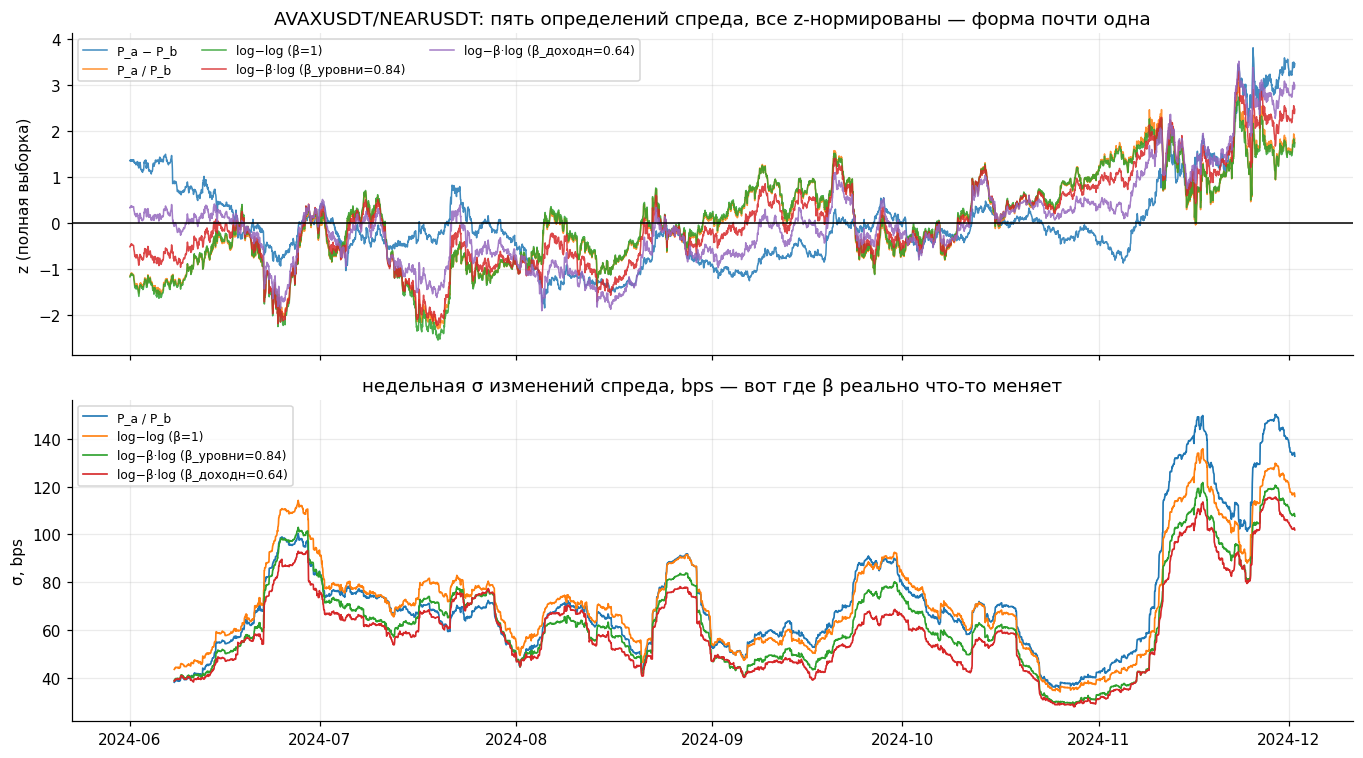

In [6]:
a, b = "AVAXUSDT", "NEARUSDT"
sub = px.loc[W[0]:W[1], [a, b]].dropna()
la, lb = np.log(sub[a]), np.log(sub[b])
b_lvl = float(np.polyfit(lb, la, 1)[0])
b_ret = float(np.polyfit(lb.diff().dropna(), la.diff().dropna(), 1)[0])
defs = {"P_a − P_b": sub[a] - sub[b], "P_a / P_b": sub[a] / sub[b],
        "log−log (β=1)": la - lb, f"log−β·log (β_уровни={b_lvl:.2f})": la - b_lvl*lb,
        f"log−β·log (β_доходн={b_ret:.2f})": la - b_ret*lb}
fig, ax = plt.subplots(2, 1, figsize=(12.5, 7), sharex=True)
for tag, s in defs.items():
    ax[0].plot(s.index, ((s - s.mean())/s.std()).values, lw=1.0, label=tag, alpha=0.85)
ax[0].axhline(0, color="black", lw=1)
ax[0].set_title(f"{a}/{b}: пять определений спреда, все z-нормированы — форма почти одна")
ax[0].set_ylabel("z (полная выборка)"); ax[0].legend(fontsize=8, ncol=3)

for tag, s in defs.items():
    if tag.startswith("P_a −"):
        continue
    ds = s.diff() / s.abs().mean() if tag.startswith("P_a /") else s.diff()
    ax[1].plot(s.index, (ds.rolling(24*7).std()*1e4).values, lw=1.1, label=tag)
ax[1].set_title("недельная σ изменений спреда, bps — вот где β реально что-то меняет")
ax[1].set_ylabel("σ, bps"); ax[1].legend(fontsize=8)
show("nb02_definitions")

## 2. Месячный протокол: отбор в месяце `x`, торговля в месяце `x+1`

Правила зафиксированы **до** просмотра результатов:

- **Отбор (месяц `x`):** Engle-Granger на часовых лог-ценах этого месяца.
  Берём пары с `p < 0.05`. Оттуда же берём `β`, `mean`, `σ` спреда.
- **Торговля (месяц `x+1`):** β / mean / σ **заморожены** с месяца `x`
  (никакого подглядывания вперёд). `z = (спред − mean) / σ`.
- **Вход** при `|z| > 2` на закрытии часа; знак: `z>0` → шорт спреда
  (продаём ногу A, покупаем ногу B), `z<0` → лонг спреда.
- **Выход** при `|z| < 0.5`, либо форс-выход в последний час месяца.
- Одна позиция за раз; после выхода можно входить снова.
- **Косты** 21 bps от gross notional за round-trip.
- PnL считаем в **% от gross notional** (см. §1.5 — подразумевает ребалансировку).

In [7]:
MONTHS = [str(p) for p in pd.period_range("2024-01", "2025-06", freq="M")]
lp = np.log(px[liq])


def month_slice(df, ym):
    p = pd.Period(ym, freq="M")
    lo = pd.Timestamp(p.start_time, tz="UTC")
    hi = pd.Timestamp(p.end_time, tz="UTC")
    return df.loc[lo:hi]


def trade_month(s: pd.Series, mu: float, sd: float, g: float,
                zin: float = 2.0, zout: float = 0.5) -> pd.DataFrame:
    """Сделки по замороженному z внутри одного месяца. Возвращает журнал сделок."""
    z = (s - mu) / sd
    zv, sv, idx, n = z.values, s.values, s.index, len(s)
    trades, i = [], 0
    while i < n:
        if abs(zv[i]) > zin:
            side = -1 if zv[i] > 0 else 1        # -1 = шорт спреда, +1 = лонг спреда
            j = i + 1
            while j < n and abs(zv[j]) >= zout:
                j += 1
            k = min(j, n - 1)
            gross_pnl = side * (sv[k] - sv[i]) / g * 100
            trades.append({"t_in": idx[i], "t_out": idx[k], "hours": k - i, "side": side,
                           "z_in": zv[i], "z_out": zv[k], "s_in": sv[i], "s_out": sv[k],
                           "pnl_gross_pct": gross_pnl,
                           "pnl_net_pct": gross_pnl - ROUND_TRIP_BPS / 100,
                           "forced": j >= n})
            i = k + 1
        else:
            i += 1
    return pd.DataFrame(trades)


t0 = time.time()
recs = []
for m_form, m_trade in zip(MONTHS[:-1], MONTHS[1:]):
    f = month_slice(lp, m_form)
    t = month_slice(lp, m_trade)
    for a, b in combinations(liq, 2):
        ylab, xlab = (a, b) if daily_m[a] <= daily_m[b] else (b, a)
        yv, xv = f[ylab].values, f[xlab].values
        p = coint(yv, xv, trend="c", maxlag=1, autolag=None)[1]
        if p >= 0.05:
            continue
        beta, const = np.polyfit(xv, yv, 1)
        s_f = yv - beta * xv
        mu, sd = s_f.mean(), s_f.std()
        g = gross([1.0, -beta])
        s_t = t[ylab] - beta * t[xlab]
        tr = trade_month(s_t, mu, sd, g)
        recs.append({"m_form": m_form, "m_trade": m_trade, "y": ylab, "x": xlab,
                     "p": p, "beta": beta, "mu": mu, "sd": sd, "g": g,
                     "n_trades": len(tr),
                     "pnl_net_pct": tr.pnl_net_pct.sum() if len(tr) else 0.0,
                     "trades": tr})
R = pd.DataFrame(recs)
print(f"протокол прогнан за {time.time()-t0:.0f}s")
print(f"пар-месяцев с коинтеграцией (p<0.05 в месяце отбора): {len(R)}")
print(f"из них дали хотя бы одну сделку в следующем месяце: {(R.n_trades>0).sum()}")
print(f"всего сделок: {R.n_trades.sum()}")

протокол прогнан за 7s
пар-месяцев с коинтеграцией (p<0.05 в месяце отбора): 1751
из них дали хотя бы одну сделку в следующем месяце: 1695
всего сделок: 4068


In [8]:
act = R[R.n_trades > 0].copy()
allt = pd.concat(act.trades.tolist(), ignore_index=True)
print(f"ИТОГ ПО ВСЕМ СДЕЛКАМ ПРОТОКОЛА (n={len(allt)}, TRAIN, косты учтены)")
print(f"  среднее   {allt.pnl_net_pct.mean():+.3f}% от gross")
print(f"  медиана   {allt.pnl_net_pct.median():+.3f}%")
print(f"  доля плюсовых {(allt.pnl_net_pct>0).mean()*100:.1f}%")
print(f"  std {allt.pnl_net_pct.std():.2f}%,  среднее/std = {allt.pnl_net_pct.mean()/allt.pnl_net_pct.std():+.3f}")
print(f"  медиана удержания {allt.hours.median():.0f} ч; форс-выходов в конце месяца "
      f"{allt.forced.mean()*100:.0f}%")

bym = act.groupby("m_trade").agg(пар=("y", "size"), сделок=("n_trades", "sum"),
                                 средний_pnl=("pnl_net_pct", "mean"))
bym["средний_pnl"] = bym.средний_pnl.round(2)
print("\nПО МЕСЯЦАМ ТОРГОВЛИ (средний net PnL на пару-месяц, % от gross):")
print(bym.to_string())
print(f"\nположительных месяцев: {(bym.средний_pnl>0).sum()} из {len(bym)}")

ИТОГ ПО ВСЕМ СДЕЛКАМ ПРОТОКОЛА (n=4068, TRAIN, косты учтены)
  среднее   -0.600% от gross
  медиана   +2.184%
  доля плюсовых 70.4%
  std 10.46%,  среднее/std = -0.057
  медиана удержания 113 ч; форс-выходов в конце месяца 34%

ПО МЕСЯЦАМ ТОРГОВЛИ (средний net PnL на пару-месяц, % от gross):
         пар  сделок  средний_pnl
m_trade                          
2024-02  102     184        -6.74
2024-03   91     322        -4.07
2024-04   91     163        -0.96
2024-05  105     203        -4.22
2024-06   60     121        -6.69
2024-07   65     174         2.10
2024-08   94     262         0.03
2024-09  106     215         4.74
2024-10   52     113         0.03
2024-11  132     504       -14.86
2024-12   85     242         4.94
2025-01  179     308         1.01
2025-02  100     300         0.54
2025-03  136     257         1.57
2025-04  156     381         0.65
2025-05   69     158         1.17
2025-06   72     161        -2.56

положительных месяцев: 10 из 17


## 3. Механика на графиках: одна пара, месяц торговли

Четыре панели, синхронные по времени:

1. **нога A** (`y`) — её цена; ▼ = продали, ▲ = купили, ✕ = закрыли;
2. **нога B** (`x`) — та же сделка, но противоположная сторона;
3. **спред** с замороженными уровнями `mean`, `±2σ` (вход), `±0.5σ` (выход);
4. **накопленный PnL** в % от gross notional, с учётом костов.

Примеры выбраны **не вручную**: из таблицы §2 берём лучший, медианный и худший
результат по месяцу — чтобы увидеть и как работает, и как ломается.

In [9]:
def show_mechanics(rec, tag: str):
    """4 панели механики для одной записи протокола (пара + месяц торговли)."""
    y, x, m_t, m_f = rec.y, rec.x, rec.m_trade, rec.m_form
    tr = rec.trades
    sub = month_slice(px[[y, x]], m_t)
    s = np.log(sub[y]) - rec.beta * np.log(sub[x])

    fig, ax = plt.subplots(4, 1, figsize=(13, 11), sharex=True,
                           gridspec_kw={"height_ratios": [1, 1, 1.3, 0.9]})
    ax[0].plot(sub.index, sub[y].values, lw=1.1, color="#2980b9")
    ax[0].set_ylabel(f"{y}, $")
    ax[1].plot(sub.index, sub[x].values, lw=1.1, color="#e67e22")
    ax[1].set_ylabel(f"{x}, $")
    ax[2].plot(s.index, s.values, lw=1.0, color="#2c3e50")
    for k, st, lab in [(0, "-", "mean (отбор)"), (2, "--", "±2σ вход"), (-2, "--", None),
                       (0.5, ":", "±0.5σ выход"), (-0.5, ":", None)]:
        ax[2].axhline(rec.mu + k*rec.sd, color="#c0392b", ls=st, lw=1, label=lab)
    ax[2].set_ylabel("log-спред"); ax[2].legend(fontsize=8, loc="upper right")

    for _, t in tr.iterrows():
        # позиция: нога y = side*1, нога x = side*(-beta).
        # ВАЖНО: при beta < 0 обе ноги оказываются в ОДНУ сторону (это не хедж).
        pos_y = t.side
        pos_x = t.side * (-rec.beta)
        my = "^" if pos_y > 0 else "v"
        mx = "^" if pos_x > 0 else "v"
        cy = "#27ae60" if pos_y > 0 else "#c0392b"
        cx = "#27ae60" if pos_x > 0 else "#c0392b"
        ax[0].scatter([t.t_in], [sub[y].loc[t.t_in]], marker=my, s=110, color=cy, zorder=5)
        ax[0].scatter([t.t_out], [sub[y].loc[t.t_out]], marker="X", s=90, color="black", zorder=5)
        ax[1].scatter([t.t_in], [sub[x].loc[t.t_in]], marker=mx, s=110, color=cx, zorder=5)
        ax[1].scatter([t.t_out], [sub[x].loc[t.t_out]], marker="X", s=90, color="black", zorder=5)
        ax[2].scatter([t.t_in], [t.s_in], marker="v" if t.side < 0 else "^", s=110,
                      color="#c0392b" if t.side < 0 else "#27ae60", zorder=5)
        ax[2].scatter([t.t_out], [t.s_out], marker="X", s=90, color="black", zorder=5)
        ax[2].plot([t.t_in, t.t_out], [t.s_in, t.s_out], color="black", lw=0.8, alpha=0.4)

    # накопленный PnL по часам: позиция активна между входом и выходом
    pos = pd.Series(0.0, index=s.index)
    for _, t in tr.iterrows():
        pos.loc[t.t_in:t.t_out] = t.side
    pnl_h = (pos.shift(1).fillna(0) * s.diff().fillna(0)) / rec.g * 100
    fees = pd.Series(0.0, index=s.index)
    for _, t in tr.iterrows():
        fees.loc[t.t_out] -= ROUND_TRIP_BPS / 100
    cum = (pnl_h + fees).cumsum()
    ax[3].plot(cum.index, cum.values, lw=1.4, color="#16a085")
    ax[3].axhline(0, color="black", lw=1)
    ax[3].set_ylabel("накопл. PnL,\n% от gross")
    warn = "  ⚠ β<0: обе ноги в одну сторону, это НЕ хедж" if rec.beta < 0 else ""
    ax[0].set_title(f"{tag}: {y} / {x} | отбор {m_f} (p={rec.p:.4f}, β={rec.beta:.3f}){warn} | "
                    f"торговля {m_t}, сделок {len(tr)}, итог {rec.pnl_net_pct:+.2f}% от gross")
    show(f"nb02_mech_{tag}")

    cols = ["t_in", "t_out", "hours", "side", "z_in", "z_out", "pnl_gross_pct",
            "pnl_net_pct", "forced"]
    tt = tr[cols].copy()
    tt["t_in"] = tt.t_in.dt.strftime("%m-%d %H:%M")
    tt["t_out"] = tt.t_out.dt.strftime("%m-%d %H:%M")
    tt["side"] = tt.side.map({-1: "шорт спреда", 1: "лонг спреда"})
    print(f"\nЖУРНАЛ СДЕЛОК — {tag}: {y}/{x}, торговля {m_t}")
    print(tt.round(2).to_string(index=False))
    # проверка руками: PnL по ногам должен совпасть с PnL по спреду
    print("\nсверка первой сделки по ногам (лог-доходности):")
    t = tr.iloc[0]
    ry = np.log(sub[y].loc[t.t_out] / sub[y].loc[t.t_in])
    rx = np.log(sub[x].loc[t.t_out] / sub[x].loc[t.t_in])
    chk = t.side * (ry - rec.beta * rx) / rec.g * 100
    print(f"  нога {y}: {ry*100:+.2f}%  |  нога {x}: {rx*100:+.2f}%  |  β={rec.beta:.3f}")
    print(f"  PnL = side*(r_y − β·r_x)/gross = {chk:+.3f}%  "
          f"(из журнала {t.pnl_gross_pct:+.3f}%)")

выбранные примеры (по итогу месяца, % от gross):
  ЛУЧШИЙ     JASMYUSDT/JTOUSDT  отбор 2024-03 → торг 2024-04: +58.00% (6 сделок)
  МЕДИАННЫЙ  DOTUSDT/BNBUSDT  отбор 2025-02 → торг 2025-03: +1.00% (2 сделок)
  ХУДШИЙ     XLMUSDT/WLDUSDT  отбор 2024-10 → торг 2024-11: -142.01% (1 сделок)


[saved] notebooks\statarb\_out\nb02_mech_median.png

ЖУРНАЛ СДЕЛОК — median: DOTUSDT/BNBUSDT, торговля 2025-03
       t_in       t_out  hours        side  z_in  z_out  pnl_gross_pct  pnl_net_pct  forced
03-09 17:00 03-27 00:00    415 лонг спреда -2.02  -0.47           4.97         4.76   False
03-28 05:00 03-31 23:00     90 лонг спреда -2.04  -3.14          -3.55        -3.76    True

сверка первой сделки по ногам (лог-доходности):
  нога DOTUSDT: +17.01%  |  нога BNBUSDT: +11.80%  |  β=0.718
  PnL = side*(r_y − β·r_x)/gross = +4.971%  (из журнала +4.971%)


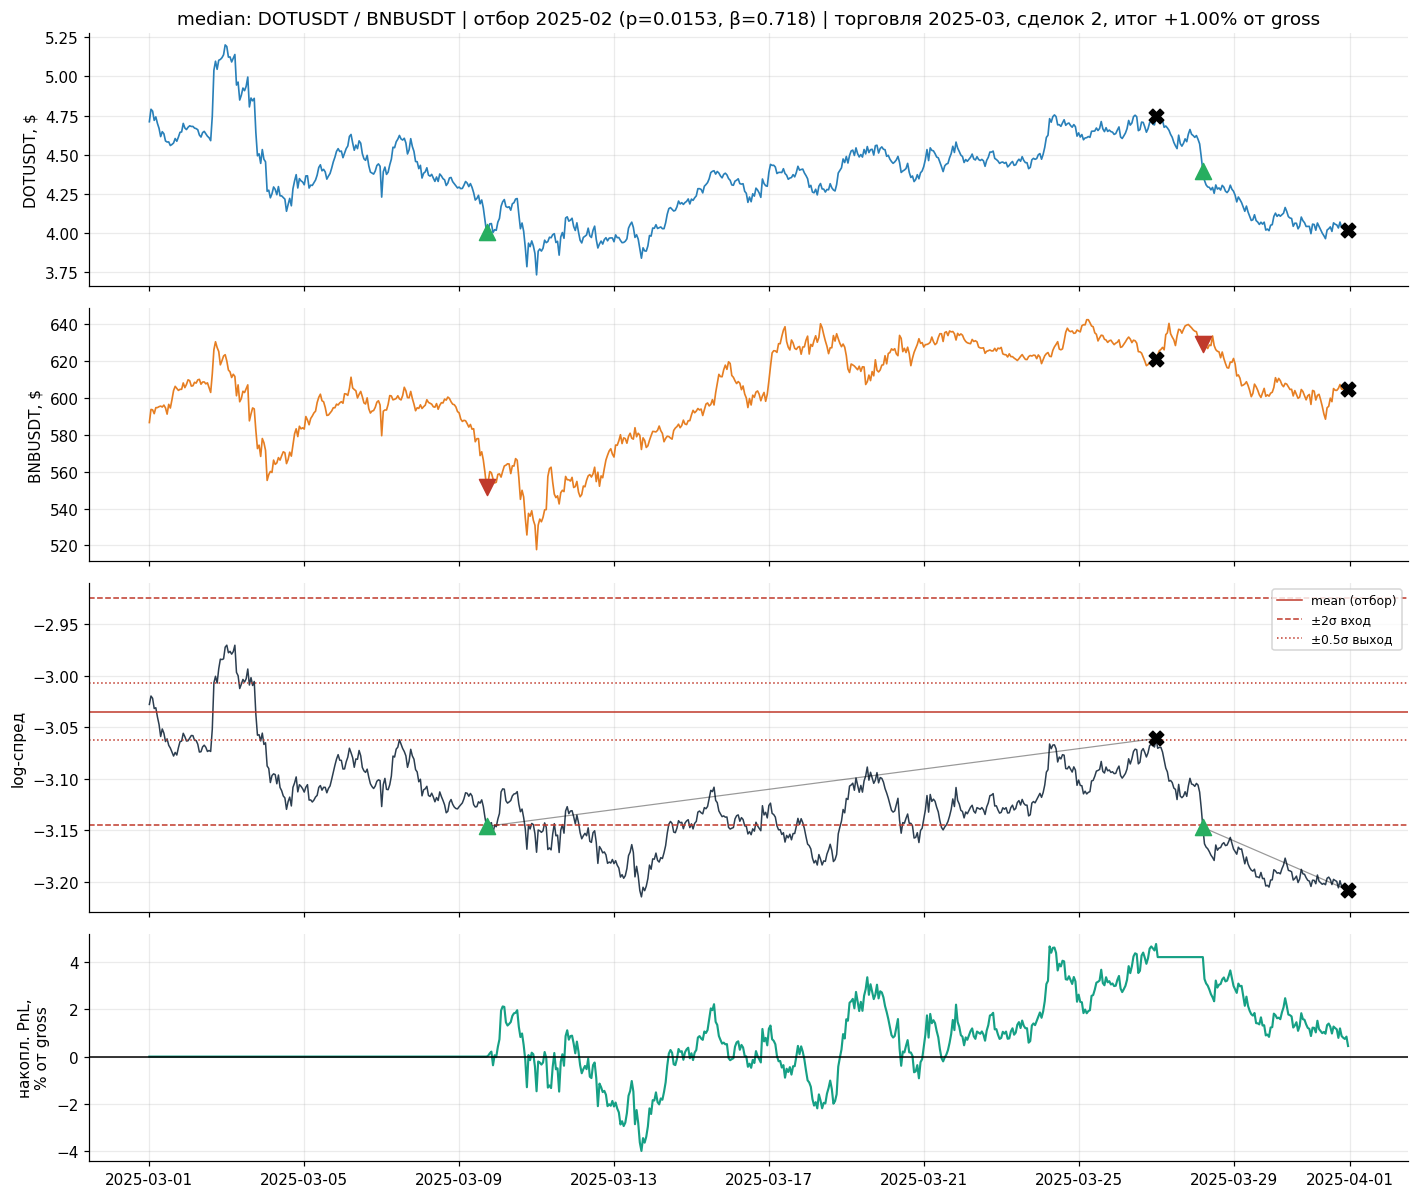

In [10]:
act_s = act.sort_values("pnl_net_pct").reset_index(drop=True)
best = act_s.iloc[-1]
med = act_s.iloc[len(act_s)//2]
worst = act_s.iloc[0]
print("выбранные примеры (по итогу месяца, % от gross):")
for tag, r in [("ЛУЧШИЙ", best), ("МЕДИАННЫЙ", med), ("ХУДШИЙ", worst)]:
    print(f"  {tag:<10} {r.y}/{r.x}  отбор {r.m_form} → торг {r.m_trade}: "
          f"{r.pnl_net_pct:+.2f}% ({r.n_trades} сделок)")
show_mechanics(med, "median")

[saved] notebooks\statarb\_out\nb02_mech_best.png

ЖУРНАЛ СДЕЛОК — best: JASMYUSDT/JTOUSDT, торговля 2024-04
       t_in       t_out  hours        side  z_in  z_out  pnl_gross_pct  pnl_net_pct  forced
04-01 00:00 04-02 21:00     45 шорт спреда  2.37   0.49          10.72        10.51   False
04-08 08:00 04-10 12:00     52 шорт спреда  2.01   0.46           8.89         8.68   False
04-11 02:00 04-12 20:00     42 шорт спреда  2.84  -0.29          17.95        17.74   False
04-13 20:00 04-14 22:00     26 лонг спреда -2.35  -0.34          11.51        11.30   False
04-15 18:00 04-19 10:00     88 лонг спреда -2.47  -0.50          11.28        11.07   False
04-29 06:00 04-30 23:00     41 лонг спреда -2.09  -2.28          -1.09        -1.30    True

сверка первой сделки по ногам (лог-доходности):
  нога JASMYUSDT: -12.35%  |  нога JTOUSDT: -6.46%  |  β=-0.382
  PnL = side*(r_y − β·r_x)/gross = +10.722%  (из журнала +10.722%)


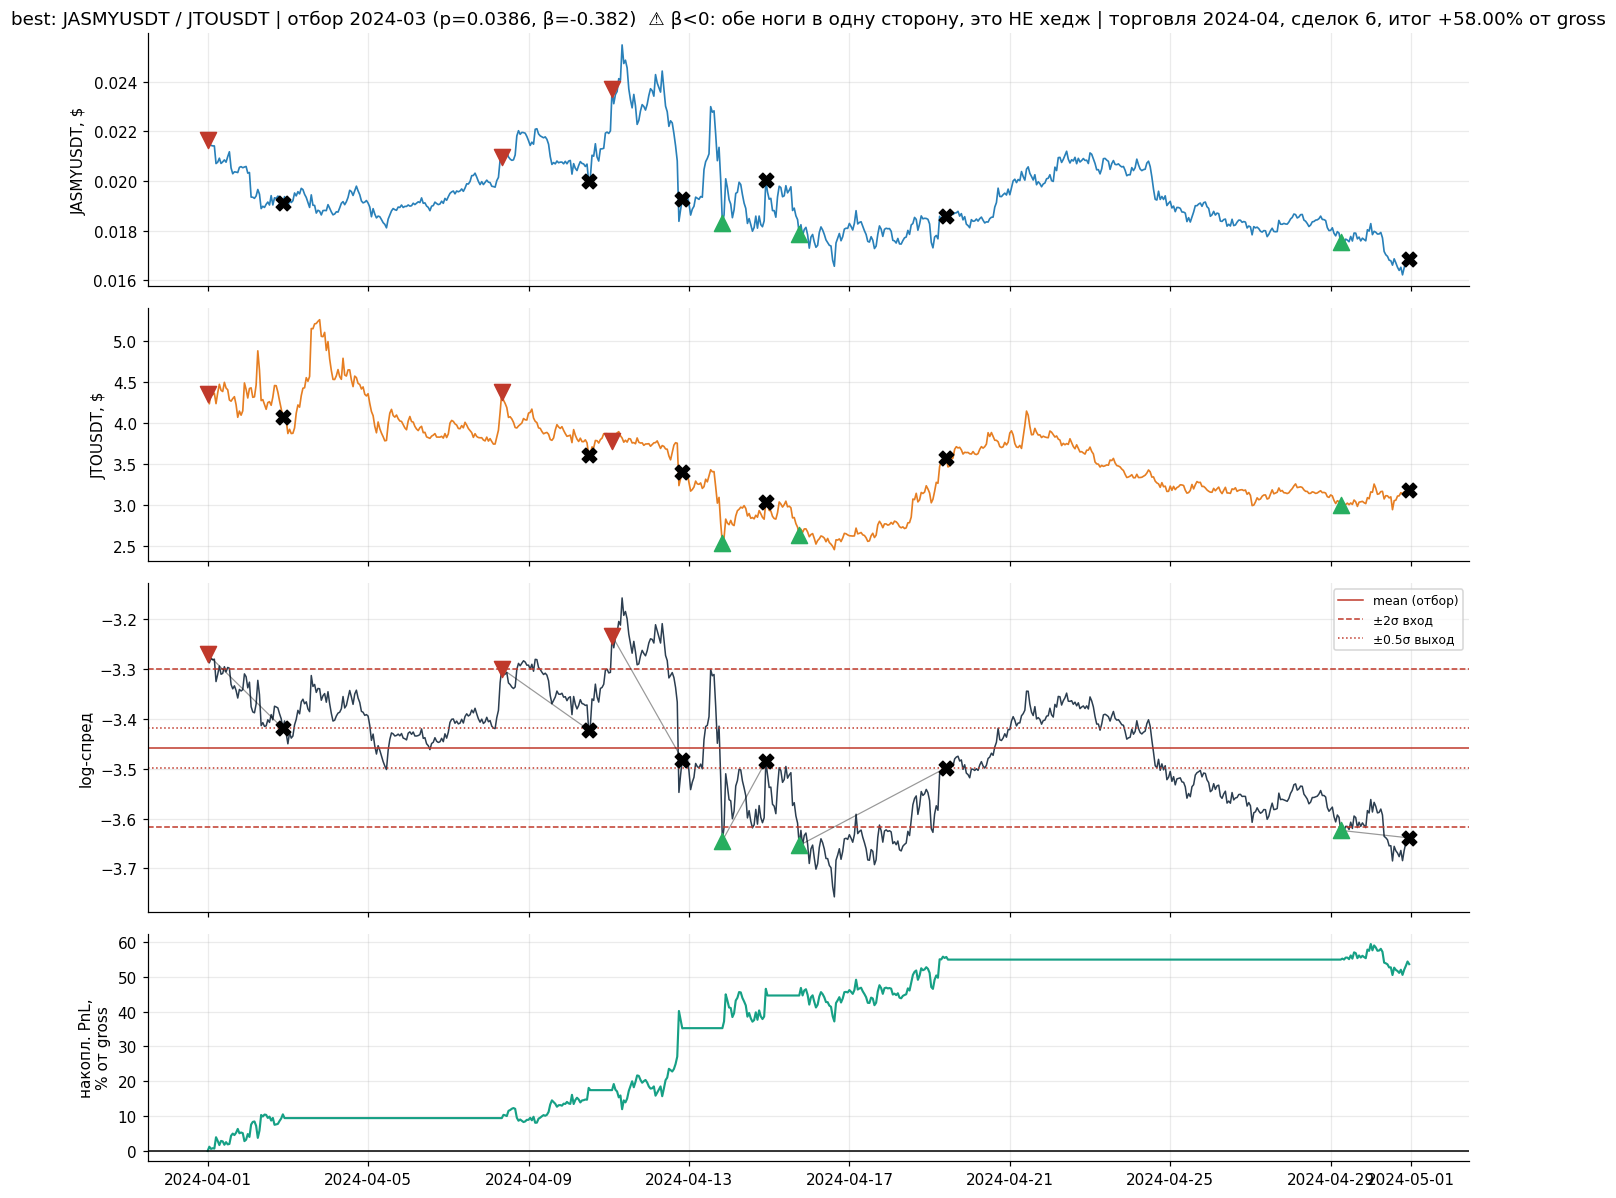

In [11]:
show_mechanics(best, "best")

[saved] notebooks\statarb\_out\nb02_mech_worst.png

ЖУРНАЛ СДЕЛОК — worst: XLMUSDT/WLDUSDT, торговля 2024-11
       t_in       t_out  hours        side  z_in  z_out  pnl_gross_pct  pnl_net_pct  forced
11-06 04:00 11-30 23:00    595 шорт спреда  2.06   83.3         -141.8      -142.01    True

сверка первой сделки по ногам (лог-доходности):
  нога XLMUSDT: +169.31%  |  нога WLDUSDT: +63.51%  |  β=0.134
  PnL = side*(r_y − β·r_x)/gross = -141.804%  (из журнала -141.804%)


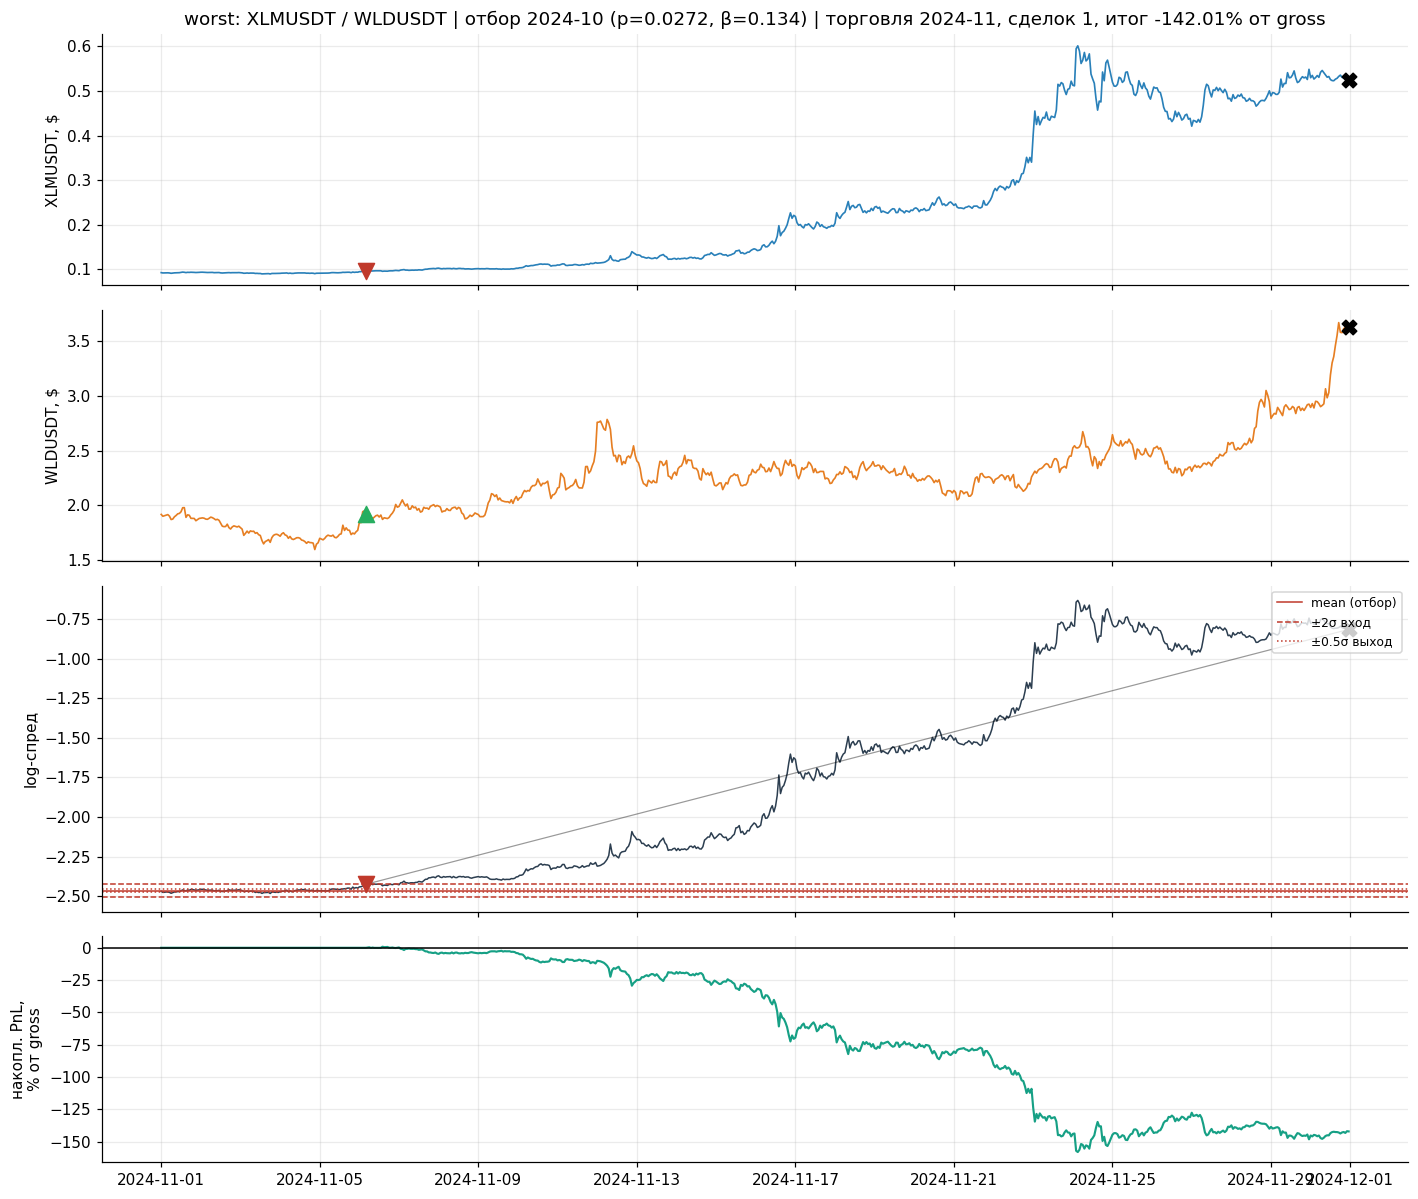

In [12]:
show_mechanics(worst, "worst")

## 4. Аудит β: отрицательная β — это не хедж, а направленная ставка

В «лучшем» примере оказалась **β = −0.382**. Вектор весов `w = (1, −β) = (1, +0.38)`,
то есть позиция «шорт спреда» = **шорт обеих ног**. Никакой рыночной нейтральности
здесь нет: такая «пара» — ставка на то, что весь рынок пойдёт вниз, и её результат
определяется рынком, а не сходимостью спреда.

Engle-Granger такие комбинации выдаёт охотно: тесту всё равно, какого знака β, ему
важна лишь стационарность остатка. Меряем, сколько их в протоколе и как они влияют
на итог.

In [13]:
neg = R[R.beta < 0]
pos = R[R.beta > 0]
print(f"пар-месяцев с коинтеграцией: {len(R)}")
print(f"  с β > 0 (настоящий хедж, ноги в разные стороны): {len(pos)} ({len(pos)/len(R)*100:.1f}%)")
print(f"  с β < 0 (ноги в ОДНУ сторону, направленная ставка): {len(neg)} ({len(neg)/len(R)*100:.1f}%)")

for d, tag in [(pos, "β>0"), (neg, "β<0")]:
    a = d[d.n_trades > 0]
    tt = pd.concat(a.trades.tolist(), ignore_index=True) if len(a) else pd.DataFrame()
    if not len(tt):
        continue
    print(f"\n{tag}: сделок {len(tt)}, среднее {tt.pnl_net_pct.mean():+.3f}%, "
          f"медиана {tt.pnl_net_pct.median():+.3f}%, "
          f"std {tt.pnl_net_pct.std():.2f}%, "
          f"худшая {tt.pnl_net_pct.min():+.1f}%")

# насколько β<0 связки экспонированы на рынок
print("\nРЫНОЧНАЯ ЭКСПОЗИЦИЯ: corr(Δспред, рыночный фактор) по знаку β")
rows = []
for d, tag in [(pos, "β>0"), (neg, "β<0")]:
    cs = []
    for _, r in d.sample(min(150, len(d)), random_state=0).iterrows():
        seg = month_slice(lp, r.m_trade)
        ds = (seg[r.y] - r.beta * seg[r.x]).diff().dropna()
        mkt = MKT.reindex(ds.index)
        cs.append(float(np.corrcoef(ds, mkt)[0, 1]))
    cs = np.array(cs)
    rows.append({"группа": tag, "выборка пар": len(cs),
                 "медиана |corr с рынком|": round(float(np.median(np.abs(cs))), 3),
                 "медиана corr": round(float(np.median(cs)), 3),
                 "доля |corr|>0.5": round(float((np.abs(cs) > 0.5).mean()) * 100, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print("\n-> β<0 связки систематически держат рыночную экспозицию: их 'спред' движется")
print("   вместе с рынком, поэтому и прибыль, и убыток там про рынок, а не про арбитраж.")
print("   Практический вывод: скан обязан отбрасывать β<=0 (или помечать отдельно).")

пар-месяцев с коинтеграцией: 1751
  с β > 0 (настоящий хедж, ноги в разные стороны): 1648 (94.1%)
  с β < 0 (ноги в ОДНУ сторону, направленная ставка): 103 (5.9%)

β>0: сделок 3800, среднее -0.566%, медиана +2.120%, std 9.79%, худшая -142.0%

β<0: сделок 268, среднее -1.087%, медиана +5.881%, std 17.37%, худшая -109.4%

РЫНОЧНАЯ ЭКСПОЗИЦИЯ: corr(Δспред, рыночный фактор) по знаку β
группа  выборка пар  медиана |corr с рынком|  медиана corr  доля |corr|>0.5
   β>0          150                    0.252         0.174             28.7
   β<0          103                    0.860         0.860             99.0

-> β<0 связки систематически держат рыночную экспозицию: их 'спред' движется
   вместе с рынком, поэтому и прибыль, и убыток там про рынок, а не про арбитраж.
   Практический вывод: скан обязан отбрасывать β<=0 (или помечать отдельно).
